# 02. Loading Engineering Datasets
**Engineering Data Processing with Python** | one-day course | approx. 50 minutes

> **SOLUTION NOTEBOOK.** Every blank and TODO is filled in. Try the exercise version first; use this when you are stuck or to compare approaches. There is usually more than one correct answer.


In [1]:
# ===================== SETUP: run this cell first (click it, then Shift+Enter) =====================
# It makes sure the course data is available in this Colab session and loads the tools we need.
import os, zipfile, urllib.request
from pathlib import Path

DATA_ZIP_URL = "https://raw.githubusercontent.com/buildyourai/ei-python-data-processing/main/data.zip"   # course data (fictional / public)

def get_course_data():
    if Path("data").is_dir():
        print("Data folder found:", sorted(p.name for p in Path("data").iterdir())[:20])
        return
    if not Path("data.zip").exists() and DATA_ZIP_URL:
        print("Downloading course data...")
        urllib.request.urlretrieve(DATA_ZIP_URL, "data.zip")
    zip_path = Path("data.zip")
    if not zip_path.exists():
        try:
            from google.colab import files
            print("Choose data.zip from your computer (your trainer will tell you where it is).")
            uploaded = files.upload()
            zip_path = Path(next(iter(uploaded)))
        except ImportError:
            raise FileNotFoundError("Put data.zip or the data folder next to this notebook.")
    with zipfile.ZipFile(zip_path) as z:
        z.extractall(".")
    print("Data ready:", sorted(p.name for p in Path("data").iterdir()))

get_course_data()
Path("outputs").mkdir(exist_ok=True)

import pandas as pd
import numpy as np
pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 200)

def check(condition, ok="Looks right.", hint="Not quite yet. Re-read the instructions above the cell."):
    """Tiny self-check helper used throughout the course."""
    print(("PASS: " + ok) if condition else ("NOT YET: " + hint))

Data folder found: ['3dprinter.csv', 'asset_register.xlsx', 'boiler.json', 'capstone', 'checkpoints', 'concrete.csv', 'manifest.TXT', 'manifest.csv', 'sensor_readings.csv', 'steel.csv', 'thermal-profiles.xlsx', 'work_orders_cmms.csv', 'work_orders_legacy.xlsx']


## What you will do

* Load a large CSV of energy data from a steel plant and parse its dates **correctly**.
* Find and fix a timestamp fault that no error message will ever tell you about.
* Load Excel files with title rows, multiple sheets and two-row headers.
* Load the Kilbrack work orders with the right settings for missing values and dates.

The general lesson: `pd.read_csv()` and `pd.read_excel()` will happily load almost anything. Loading without an error
does not mean loading correctly. You check.

## 1. Steel plant energy data (35,000 rows of 15-minute readings)

### Exercise 2.1 [Level 1: fill the blanks]

In [2]:
steel = pd.read_csv("data/steel.csv")
print(steel.shape)
print(steel.dtypes)
steel.head()

(35040, 11)
date                                     object
Usage_kWh                               float64
Lagging_Current_Reactive.Power_kVarh    float64
Leading_Current_Reactive_Power_kVarh    float64
CO2(tCO2)                               float64
Lagging_Current_Power_Factor            float64
Leading_Current_Power_Factor            float64
NSM                                       int64
WeekStatus                               object
Day_of_week                              object
Load_Type                                object
dtype: object


,date,Usage_kWh,Lagging_Current_Reactive.Power_kVarh,Leading_Current_Reactive_Power_kVarh,CO2(tCO2),Lagging_Current_Power_Factor,Leading_Current_Power_Factor,NSM,WeekStatus,Day_of_week,Load_Type
0,01/01/2018 00:15,3.17,2.95,0.0,0.0,73.21,100.0,900,Weekday,Monday,Light_Load
1,01/01/2018 00:30,4.00,4.46,0.0,0.0,66.77,100.0,1800,Weekday,Monday,Light_Load
2,01/01/2018 00:45,3.24,3.28,0.0,0.0,70.28,100.0,2700,Weekday,Monday,Light_Load
3,01/01/2018 01:00,3.31,3.56,0.0,0.0,68.09,100.0,3600,Weekday,Monday,Light_Load
4,01/01/2018 01:15,3.82,4.50,0.0,0.0,64.72,100.0,4500,Weekday,Monday,Light_Load


`date` is `object` (text). Until it is a real datetime you cannot sort by time properly, resample to daily totals
or calculate durations.

### The date order trap

Irish and UK exports usually write day/month/year. pandas, left to guess, often assumes month/day/year.
Watch what happens to the 1st of February:

In [3]:
sample = pd.Series(["01/02/2018 00:15", "13/02/2018 00:15"])
print(pd.to_datetime(sample.iloc[:1]))                     # guessed: becomes 2 January
print(pd.to_datetime(sample, format="%d/%m/%Y %H:%M"))     # told explicitly: 1 and 13 February

0   2018-01-02 00:15:00
dtype: datetime64[ns]
0   2018-02-01 00:15:00
1   2018-02-13 00:15:00
dtype: datetime64[ns]


The first guess is wrong and there is **no error**. Day 13 would have exposed it, but days 1 to 12 parse without complaint in
the wrong month. Always give an explicit `format` when you know it.

Format codes: `%d` day, `%m` month, `%Y` 4-digit year, `%H` hour (24h), `%M` minute, `%S` second.

### Exercise 2.2 [Level 1: fill the blanks]

In [4]:
steel["date"] = pd.to_datetime(steel["date"], format="%d/%m/%Y %H:%M")
print(steel["date"].dtype)
print("From", steel["date"].min(), "to", steel["date"].max())

datetime64[ns]
From 2018-01-01 00:00:00 to 2018-12-31 23:45:00


In [5]:
check(str(steel["date"].dtype).startswith("datetime64") and steel["date"].dt.month.nunique() == 12,
      "Dates parsed, all 12 months present.", "Check the format string: day first, then month.")

PASS: Dates parsed, all 12 months present.


### A fault nobody will tell you about

Time series should go forwards. Let's check.

In [6]:
print("Is the time column always increasing?", steel["date"].is_monotonic_increasing)

steps = steel["date"].diff()                 # time between each row and the one before
backwards = steel[steps < pd.Timedelta(0)]   # rows where time went backwards
print("Rows where time goes backwards:", len(backwards))
steel.loc[94:97, ["date", "Usage_kWh", "NSM", "Day_of_week"]]

Is the time column always increasing? False
Rows where time goes backwards: 365


,date,Usage_kWh,NSM,Day_of_week
94,2018-01-01 23:45:00,3.67,85500,Monday
95,2018-01-01 00:00:00,3.42,0,Monday
96,2018-01-02 00:15:00,3.20,900,Tuesday
97,2018-01-02 00:30:00,3.85,1800,Tuesday


Look at rows 94 to 96. After `2018-01-01 23:45` comes `2018-01-01 00:00`, then `2018-01-02 00:15`.
The midnight reading is stamped with the **wrong day**: it belongs to the start of the *next* day.
The source system wrote the end-of-day reading with today's date. This happens once a day, 365 times.

`NSM` (number of seconds from midnight) is 0 on that row, which supports the diagnosis. This is how you investigate:
find the anomaly, look at the neighbours, use another column to confirm.

### Exercise 2.3 [Level 2: finish the code]

Fix it: every row whose time is exactly 00:00 should move forward one day.

* `steel["date"].dt.hour` and `steel["date"].dt.minute` give the hour and minute.
* Build a True/False *mask* for "hour is 0 **and** minute is 0" (use `&` and brackets around each condition).
* Add `pd.Timedelta(days=1)` to those rows using `steel.loc[mask, "date"]`.

In [7]:
midnight = (steel["date"].dt.hour == 0) & (steel["date"].dt.minute == 0)
steel.loc[midnight, "date"] = steel.loc[midnight, "date"] + pd.Timedelta(days=1)

print("Monotonic now?", steel["date"].is_monotonic_increasing)
print("Last timestamp:", steel["date"].max())

Monotonic now? True
Last timestamp: 2019-01-01 00:00:00


In [8]:
gaps = steel["date"].diff().dropna()
check(steel["date"].is_monotonic_increasing and steel["date"].max() == pd.Timestamp("2019-01-01 00:00")
      and (gaps == pd.Timedelta(minutes=15)).all(),
      "Every step is exactly 15 minutes and the year ends at 2019-01-01 00:00.",
      "Not fixed yet. Did you add one day to the midnight rows only?")

PASS: Every step is exactly 15 minutes and the year ends at 2019-01-01 00:00.


## 2. Quick profiling of the steel data

### Exercise 2.4 [Level 1: fill the blanks]
Daily energy use. `resample("D")` groups a time series by day (like a pivot table on dates).

*A detail that matters:* each reading is stamped at the **end** of its 15-minute interval, so the 00:00 reading
belongs to the day before. `closed="right", label="left"` tells pandas that. Skip it and every daily total is
shifted by one reading. For a utility bill reconciliation, that matters.

365 days


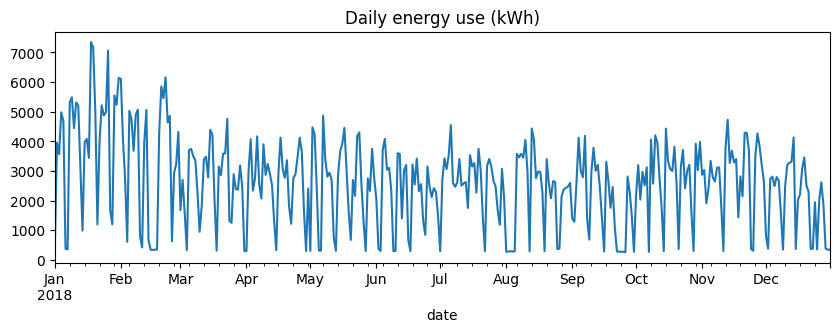

In [9]:
daily_kwh = (steel.set_index("date")["Usage_kWh"]
                  .resample("D", closed="right", label="left")
                  .sum())
print(len(daily_kwh), "days")
daily_kwh.plot(title="Daily energy use (kWh)", figsize=(10, 3));

In [10]:
check(len(daily_kwh) == 365, "365 days. The weekly pattern (weekends lower) is visible.", "Expected 365 days.")

PASS: 365 days. The weekly pattern (weekends lower) is visible.


In [11]:
steel["Load_Type"].value_counts()

Load_Type
Light_Load      18072
Medium_Load      9696
Maximum_Load     7272
Name: count, dtype: int64

## 3. Excel with title rows: the Kilbrack asset register

### Exercise 2.5 [Level 1: fill the blanks]
First, load it the naive way and look at the column names.

In [12]:
naive = pd.read_excel("data/asset_register.xlsx")
naive.head(6)

,Kilbrack Engineering Ltd - Asset Register (FICTIONAL TRAINING DATA),Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8
0,Exported from CMMS on 30/09/2026 by maintenanc...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Asset ID,Asset Description,Asset Type,Site,Install Date,Manufacturer,Rated Power,Criticality,Status
3,CNC-001,CNC Mill 1,CNC Mill,Galway,2018-06-19 00:00:00,Hartwell Machine Tools,38 kW,C,In Service
4,CNC-002,CNC Mill 2,CNC Mill,Cork Plant,2011-03-22 00:00:00,Hartwell Machine Tools,36kW,C,In Service
5,CNC-003,CNC Mill 3,CNC Mill,Limerick,22/06/2019,Hartwell Machine Tools,38000 W,A,In Service


The real header is on the 4th row of the sheet. Above it are a title and an export note. Tell pandas to skip them.

In [13]:
register = pd.read_excel("data/asset_register.xlsx", skiprows=3)
print(register.columns.tolist())
register.head()

['Asset ID', 'Asset Description', 'Asset Type', 'Site', 'Install Date', 'Manufacturer', 'Rated Power', 'Criticality', 'Status']


,Asset ID,Asset Description,Asset Type,Site,Install Date,Manufacturer,Rated Power,Criticality,Status
0,CNC-001,CNC Mill 1,CNC Mill,Galway,2018-06-19 00:00:00,Hartwell Machine Tools,38 kW,C,In Service
1,CNC-002,CNC Mill 2,CNC Mill,Cork Plant,2011-03-22 00:00:00,Hartwell Machine Tools,36kW,C,In Service
2,CNC-003,CNC Mill 3,CNC Mill,Limerick,22/06/2019,Hartwell Machine Tools,38000 W,A,In Service
3,CNC-004,CNC Mill 4,CNC Mill,Galway,2016-01-01,Hartwell Machine Tools,28.5,C,In Service
4,CNC-005,CNC Mill 5,CNC Mill,Limerick,08.06.2014,Hartwell Machine Tools,34.5 kW,B,In Service


In [14]:
check("Asset ID" in register.columns, "Header found.", "Expected a column called 'Asset ID'. How many rows are above the header?")

PASS: Header found.


Excel files often have more than one sheet. `sheet_name=None` loads **all** sheets into a dictionary
(sheet name: DataFrame).

In [15]:
all_sheets = pd.read_excel("data/asset_register.xlsx", sheet_name=None, skiprows=3)
print(list(all_sheets.keys()))

['Register', 'Decommissioned']


Careful: `skiprows=3` applied to *every* sheet, but the `Decommissioned` sheet has its header on row 1.
Load that one on its own.

In [16]:
decommissioned = pd.read_excel("data/asset_register.xlsx", sheet_name="Decommissioned")
decommissioned

,Asset ID,Asset Description,Asset Type,Site,Install Date,Manufacturer,Rated Power,Criticality,Status,Decommissioned On
0,CNC-015,CNC Mill (old),CNC Mill,Cork,2005-06-01,Hartwell Machine Tools,20 kW,C,Decommissioned,2025-06-30
1,CMP-009,Air Compressor (old),Air Compressor,Cork,2005-06-01,Nordvik Air,20 kW,C,Decommissioned,2025-06-30
2,CNV-011,Conveyor (old),Conveyor,Cork,2005-06-01,Linea Conveyors,20 kW,C,Decommissioned,2025-06-30
3,PMP-011,Pump (old),Pump,Cork,2005-06-01,Corrib Pumps,20 kW,C,Decommissioned,2025-06-30
4,HYP-009,Hydraulic Press (old),Hydraulic Press,Cork,2005-06-01,Dunmore Hydraulics,20 kW,C,Decommissioned,2025-06-30


In [17]:
register.dtypes

Asset ID             object
Asset Description    object
Asset Type           object
Site                 object
Install Date         object
Manufacturer         object
Rated Power          object
Criticality          object
Status               object
dtype: object

`Install Date` and `Rated Power` are `object`. Some cells are real Excel dates, some are text in different formats,
and power arrives as `38 kW`, `38kW`, `38000 W` and plain `38`. We fix those in Module 03.

## 4. Excel with a two-row header: thermocouple data from casting trials

`thermal-profiles.xlsx` holds cooling curves for three aluminium-silicon alloys. Each sheet has a title, a blank row,
a row of thermocouple **positions** (mm) and then the real header. Have a look:

In [18]:
pd.read_excel("data/thermal-profiles.xlsx", sheet_name="Al-11wt.%Si", header=None, nrows=6)

,0,1,2,3,4,5,6,7
0,Thermal profile of the Al-11wt.%Si alloy,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Thermopar position [mm],4,15,19,22,39,54,69
3,Time [s],Thermopar #1 [°C],Thermopar #2 [°C],Thermopar #3 [°C],Thermopar #4 [°C],Thermopar #5 [°C],Thermopar #6 [°C],Thermopar #7 [°C]
4,0,634.0735,639.0715,640.6152,640.8339,646.7818,647.9475,649.089
5,0.2,631.0739,639.2209,640.9079,640.9835,646.9308,647.8099,649.2386


### Exercise 2.6 [Level 2: finish the code]

1. Load the sheet `Al-11wt.%Si` using row 4 as the header (`header=3`, counting from zero).
2. Read the positions row separately (`header=None, nrows=3`, then the last row).
3. Rename columns to `time_s`, then `tc1_4mm`, `tc2_15mm`, and so on, so the position travels with the data.

In [19]:
SHEET = "Al-11wt.%Si"
thermal = pd.read_excel("data/thermal-profiles.xlsx", sheet_name=SHEET, header=3)

top = pd.read_excel("data/thermal-profiles.xlsx", sheet_name=SHEET, header=None, nrows=3)
positions_mm = top.iloc[2, 1:].tolist()
print("Positions (mm):", positions_mm)

new_cols = ["time_s"]
for i, pos in enumerate(positions_mm, start=1):
    new_cols.append(f"tc{i}_{int(pos)}mm")
thermal.columns = new_cols

thermal.head()

Positions (mm): [np.float64(4.0), np.float64(15.0), np.float64(19.0), np.float64(22.0), np.float64(39.0), np.float64(54.0), np.float64(69.0)]


,time_s,tc1_4mm,tc2_15mm,tc3_19mm,tc4_22mm,tc5_39mm,tc6_54mm,tc7_69mm
0,0.0,634.0735,639.0715,640.6152,640.8339,646.7818,647.9475,649.0890
1,0.2,631.0739,639.2209,640.9079,640.9835,646.9308,647.8099,649.2386
2,0.4,625.9844,639.3793,640.9228,640.9983,646.8026,647.9683,649.3971
3,0.6,620.2867,639.0656,640.6093,640.8279,646.4898,647.9416,649.0830
4,0.8,615.1943,638.6472,640.7645,640.8398,646.5017,647.9534,649.0949


In [20]:
check(thermal.shape == (2001, 8) and thermal.columns[0] == "time_s" and thermal.columns[1] == "tc1_4mm",
      "Loaded with meaningful names.", "Expected 2001 rows, 8 columns, first two named time_s and tc1_4mm.")

PASS: Loaded with meaningful names.


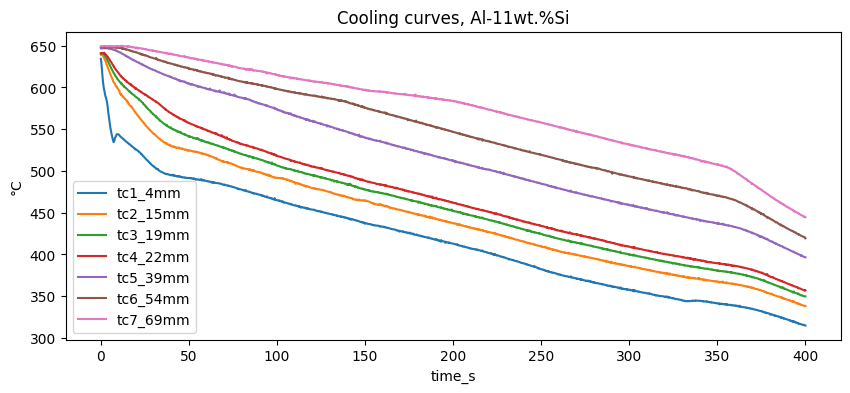

In [21]:
thermal.set_index("time_s").plot(figsize=(10, 4), title="Cooling curves, Al-11wt.%Si", ylabel="°C");

## 5. The Kilbrack work orders, loaded properly

Default settings already treat blank cells and `N/A` as missing. This export also uses `-` for "nothing".
`na_values` adds extra markers.

### Exercise 2.7 [Level 1: fill the blanks]

In [22]:
wo = pd.read_csv("data/work_orders_cmms.csv", na_values=["-"])
print(wo.shape)
print("Missing parts cost:", wo["parts_cost_eur"].isna().sum())
wo.head()

(1016, 12)
Missing parts cost: 92


,wo_id,asset_id,wo_type,priority,date_raised,date_closed,status,labour_hours,parts_cost_eur,technician,description,last_modified
0,WO-25-00270,PMP-005,PM,3,23/06/2025 13:15,24/06/2025 01:17,Closed,2.5,222.81,Gráinne FitzGerald,Quarterly PM service,2025-06-24 03:41:14
1,WO-26-00692,PMP-005,pm,4,04/03/2026 18:45,06/03/2026 06:12,CLOSED,1.5,0.77,Orla Doyle,"Replace filters, check belts",2026-03-06 09:02:03
2,WO-25-00449,PMP-001,Inspection,3,10/10/2025 10:30,11/10/2025 08:37,Closed,1.5,€0.00,Ciarán Walsh,Vibration route survey,2025-10-11 09:35:23
3,WO-25-00466,PMP-009,PM,4,18/10/2025 07:00,18/10/2025 13:04,closed,1.0,€7.48,Patrick Ryan,Annual service per OEM schedule,2025-10-18 17:15:07
4,WO-25-00198,CNV-006,Corrective,4,06/05/2025 17:45,08/05/2025 19:56,Closed,1.5,€417.25,Niamh O Connor,"Belt snapped, replaced",2025-05-08 20:18:16


### Exercise 2.8 [Level 2: finish the code]

Most `date_raised` values are `dd/mm/yyyy HH:MM`, but a few were entered as `yyyy-mm-dd HH:MM`.
A robust pattern for mixed formats:

1. Parse with the main format and `errors="coerce"` (anything that does not fit becomes `NaT`, "not a time").
2. Look at what failed.
3. Parse the failures with the second format and fill them in.
4. Count what is still missing. It should be zero, or you should know why.

In [23]:
raised = pd.to_datetime(wo["date_raised"], format="%d/%m/%Y %H:%M", errors="coerce")
failed = raised.isna()
print("Did not fit the main format:", failed.sum())
wo.loc[failed, "date_raised"].head()

Did not fit the main format: 10


124    2025-08-21 15:45
132    2026-04-16 15:50
243    2025-10-12 17:15
397    2025-04-26 17:50
470    2026-02-25 17:30
Name: date_raised, dtype: object

In [24]:
second_try = pd.to_datetime(wo.loc[failed, "date_raised"], format="%Y-%m-%d %H:%M", errors="coerce")
raised = raised.fillna(second_try)

wo["date_raised"] = raised
print("Still missing:", wo["date_raised"].isna().sum())

Still missing: 0


In [25]:
check(wo["date_raised"].isna().sum() == 0 and str(wo["date_raised"].dtype).startswith("datetime64"),
      "Every date parsed, and you know exactly which formats were in the file.",
      "Some dates are still missing. Did you fill raised with second_try?")

PASS: Every date parsed, and you know exactly which formats were in the file.


**Why not just let pandas guess?** `pd.to_datetime(col, format="mixed", dayfirst=True)` would work on this file.
It guesses each value separately. That is convenient for exploring, but in a pipeline that runs every month you
want it to **fail visibly** when a new format turns up, not guess. Explicit formats plus a count of failures
gives you that.

## 6. Stretch [Level 3: Gemini allowed]

`data/manifest.TXT` and `data/manifest.csv` both list files from a microscopy archive. The TXT is not a table, each
line looks like `diatom-01.TIF (image/tiff) 4922346 bytes.`

1. Turn the TXT into a DataFrame with columns `file_name`, `file_type`, `size_bytes` (ask Gemini for a regular
   expression, then ask it to explain each part of it).
2. Compare it with the CSV. Are the two lists the same? Is anything inconsistent inside them?

Write down what you found before looking at the solution.

In [26]:
import re

pattern = re.compile(r"^(.+?) \((.+?)\) (\d+) bytes\.$")
rows = []
with open("data/manifest.TXT") as f:
    for line in f:
        m = pattern.match(line.strip())
        if m:
            rows.append({"file_name": m.group(1), "file_type": m.group(2), "size_bytes": int(m.group(3))})
manifest_txt = pd.DataFrame(rows)

manifest_csv = pd.read_csv("data/manifest.csv", index_col=0)
print(len(manifest_txt), "files in TXT,", len(manifest_csv), "files in CSV")
print("In TXT but not CSV:", set(manifest_txt["file_name"]) - set(manifest_csv["fileNames"]))

# Inconsistency inside both: a .TIF labelled as PNG, with a different size from the other TIFs
manifest_txt[manifest_txt["file_name"].str.upper().str.endswith(".TIF")]

26 files in TXT, 25 files in CSV
In TXT but not CSV: {'TEMgrid-a part.off'}


,file_name,file_type,size_bytes
0,diatom-01.TIF,image/tiff,4922346
1,diatom-02.TIF,image/tiff,4922346
2,diatom-03.TIF,image/tiff,4922346
20,TEMgrid01.TIF,image/tiff,4922346
21,TEMgrid02.TIF,image/tiff,4922346
22,TEMgrid03.TIF,image/tiff,4922346
23,TEMgrid04.TIF,image/tiff,4922346
24,TEMgrid05.TIF,image/tiff,4922346
25,TEMgrid06.TIF,image/png,6422346


*Findings:* the TXT lists 26 files and the CSV 25 (`TEMgrid-a part.off` is missing from the CSV, possibly because of
the space in its name). `TEMgrid06.TIF` is labelled `image/png` and is 6.4 MB while every other TIF is 4.9 MB:
either the label or the file is wrong. A manifest that disagrees with itself is worth a question to whoever made it.

## Summary

* Give `to_datetime` an explicit `format`. Day/month confusion is silent.
* Check time series are monotonic and evenly spaced. Faults hide in the order of rows.
* `skiprows`, `header`, `sheet_name` and `nrows` handle most Excel layouts.
* `na_values` adds extra "missing" markers.
* For mixed formats: parse, count failures, handle them, count again.

Next: **03 Cleaning and Standardising**.